Ukuran asli: 73 x 198
Ukuran setelah resize: 4 x 10

Matrix piksel (shape): (4, 10)
[[235 193 197 179 230 231 210 228 223 242]
 [209 166 155 123 186 174 141 172 137 194]
 [211 120 152 156 182 188 175 173 133 188]
 [245 200 207 215 224 239 235 225 216 234]]


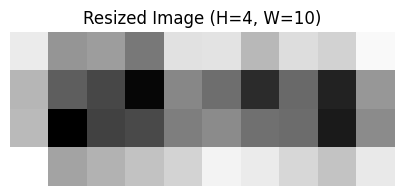

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Resize

img = Image.open("./sample_h_img_00155.png").convert("L")

w, h = img.size
print(f"Ukuran asli: {h} x {w}")

target_h = 4
target_w = int(w * (target_h / h))

img_resized = img.resize((target_w, target_h), Image.BILINEAR)

new_w, new_h = img_resized.size
print(f"Ukuran setelah resize: {new_h} x {new_w}")

img_matrix = np.array(img_resized)

print("\nMatrix piksel (shape):", img_matrix.shape)
print(img_matrix)

plt.figure(figsize=(6, 2))
plt.imshow(img_resized, cmap="gray", interpolation="nearest")
plt.title(f"Resized Image (H={new_h}, W={new_w})")
plt.axis("off")
plt.show()

In [ ]:
# Convolution

kernel = np.array([
    [ 1,  0, -1],
    [ 1,  0, -1],
    [ 1,  0, -1]
])

padding = 1
stride = 1

print("Kernel:")
print(kernel)

padded = np.pad(
    img_matrix,
    pad_width=((padding, padding), (padding, padding)),
    mode="constant",
    constant_values=0
)

print("\nInput setelah padding:")
print(padded)
print("Shape padded:", padded.shape)

H, W = img_matrix.shape
kH, kW = kernel.shape

out_h = (H + 2*padding - kH) // stride + 1
out_w = (W + 2*padding - kW) // stride + 1

conv_output = np.zeros((out_h, out_w), dtype=int)

for i in range(out_h):
    for j in range(out_w):
        conv_output[i, j] = np.sum(
            padded[i:i+kH, j:j+kW] * kernel
        )

print("\nOutput Konvolusi:")
print(conv_output)
print("Shape:", conv_output.shape)

Kernel:
[[ 1  0 -1]
 [ 1  0 -1]
 [ 1  0 -1]]

Input setelah padding:
[[  0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 235 193 197 179 230 231 210 228 223 242   0]
 [  0 209 166 155 123 186 174 141 172 137 194   0]
 [  0 211 120 152 156 182 188 175 173 133 188   0]
 [  0 245 200 207 215 224 239 235 225 216 234   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0]]
Shape padded: (6, 12)

Output Konvolusi:
[[-359   92   57  -64 -103   65    5   -9  -36  360]
 [-479  151   21  -94 -135   72   20   33  -51  493]
 [-486  151   -8  -78 -107   41   31   65  -46  486]
 [-320   97  -51  -47  -56   -4   29   61  -24  349]]
Shape: (4, 10)


In [33]:
# Batch Normalization

total_acc = 0
str_acc = ""
for i in range(conv_output.shape[0]):
    for j in range(conv_output.shape[1]):
        total_acc += conv_output[i, j]
        str_acc += str(conv_output[i, j]) + "+"
mean = total_acc / 40
print("Mean Accumulation:", str_acc)
print("Total Mean Accumulation:", total_acc)
print(f"Mean: {total_acc} / {40} = {total_acc / 40}")
print("Mean:", np.mean(conv_output), "\n")

var_acc = 0
str_acc = ""
for i in range(conv_output.shape[0]):
    for j in range(conv_output.shape[1]):
        var_acc += (conv_output[i, j] - mean) ** 2
        str_acc += str((conv_output[i, j] - mean) ** 2) + "+"
varians = var_acc / 40
print("Varians Accumulation:", str_acc)
print("Total Varians Accumulation:", var_acc)
print(f"Varians: {var_acc} / {40} = {var_acc/40}")
print("Varians:", np.var(conv_output), "\n")

epsilon = 0.001
gamma = 1.0
beta = 0.0

x_result = (-359 - 3.05) / np.sqrt(varians + 0.001)
print(f"x(-359) = -359 - 3.05 / sqrt({varians} + epsilon)")
print(f"x(-359) = {-359 - 3.05} / {np.sqrt((varians + epsilon))} = {x_result}", "\n")

y_result = 1.0 * x_result + 0.0
print(f"y = gamma * x(-359) + beta")
print(f"y = {gamma} * {x_result} + {beta} = {y_result}")


mean = np.mean(conv_output)
var = np.var(conv_output)
x_hat = (conv_output - mean) / np.sqrt(var + epsilon)
bn_output = gamma * x_hat + beta
print("\nOutput Batch Normalization:")
print(bn_output)
print("Shape:", bn_output.shape)

print("\nOutput Batch Normalization:")
print(np.round(bn_output, 3))
print("Shape:", bn_output.shape)

Mean Accumulation: -359+92+57+-64+-103+65+5+-9+-36+360+-479+151+21+-94+-135+72+20+33+-51+493+-486+151+-8+-78+-107+41+31+65+-46+486+-320+97+-51+-47+-56+-4+29+61+-24+349+
Total Mean Accumulation: 122
Mean: 122 / 40 = 3.05
Mean: 3.05 

Varians Accumulation: 131080.2025+7912.102500000001+2910.6025000000004+4495.702499999999+11246.602499999999+3837.8025000000002+3.8025000000000007+145.20250000000001+1524.9024999999997+127413.30249999999+232372.2025+21889.202499999996+322.2025+9418.7025+19057.8025+4754.1025+287.30249999999995+897.0024999999999+2921.4024999999997+240051.0025+239169.90250000003+21889.202499999996+122.10250000000002+6569.1025+12111.002499999999+1440.2025000000003+781.2025+3837.8025000000002+2405.9024999999997+233240.70249999998+104361.3025+8826.6025+2921.4024999999997+2505.0024999999996+3486.9024999999997+49.7025+673.4024999999999+3358.2025000000003+731.7025+119681.4025+
Total Varians Accumulation: 1590703.8999999997
Varians: 1590703.8999999997 / 40 = 39767.59749999999
Varians: